# 16 — Framing, viewports and locator insets

A map has to answer "where am I?" before it can say anything else. This notebook covers the three tools for
that: `set_bounds` to frame the view, `viewport` to read the framing back as a value, and `inset` / `mark_extent`
to show a detail map's place in the wider world.

By the end you will be able to frame a map on a region, inspect that framing programmatically, add a locator
inset, and cross-reference two maps' extents.

API: [`Map.set_bounds`](../reference/static_map.md), [`Map.inset`](../reference/static_map.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")


## Framing with `set_bounds`

`set_bounds` takes `[west, south, east, north]` in display-CRS units and frames the figure on it. Without it, a
map shows whatever its layers happen to span — fine for a single raster, wrong as soon as you want two figures
to be comparable.

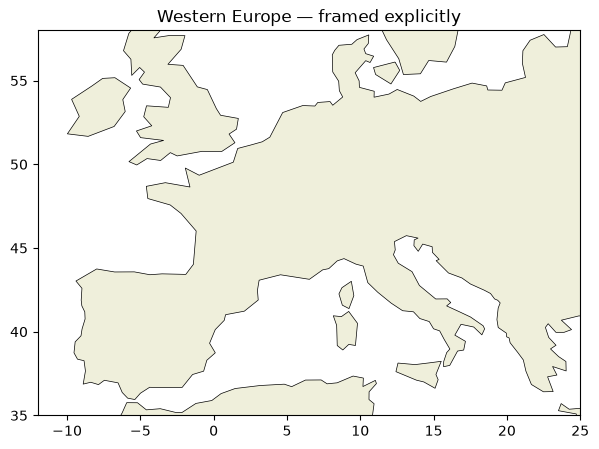

In [2]:
wide = Map(crs=4326, figsize=(7, 5))
wide.coastlines()
wide.land()
wide.set_bounds([-12, 35, 25, 58])
wide.set_title("Western Europe — framed explicitly")
wide.fig;

Two maps built with the same `set_bounds` are directly comparable, whatever they draw. That is why framing is
part of the figure's description rather than a side effect of the data.

## `padding` — framing on the data, with room to breathe

Called with no bounds, `set_bounds` frames on **everything the map draws**. `padding` adds a fractional margin so
features do not touch the frame edge.

C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


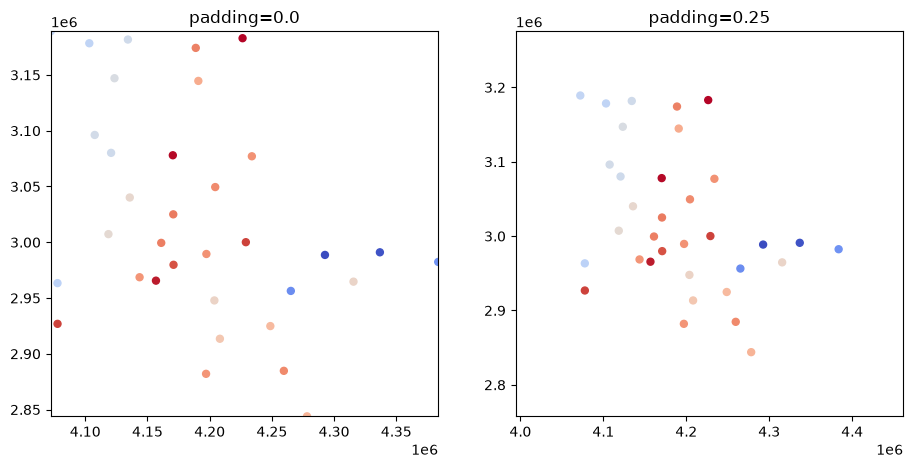

In [3]:
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pad in zip(axes, (0.0, 0.25)):
    panel = Map(ax=ax, crs=gauges.crs.to_epsg())
    panel.points(gauges, size=25)
    panel.set_bounds(padding=pad)
    ax.set_title(f"padding={pad}")
fig;

On the left the outermost gauges sit on the frame; on the right a quarter-extent margin gives them air. Padding
is the difference between a plot and a map a reader can orient in.

## Reading the framing back — `viewport`

`viewport` returns the framing **as a value**: the CRS, the bounds, whether the map is a globe. It is how code
asks a figure where it is looking, rather than inferring it from the axes.

crs:    4326
bounds: Bounds(xmin=-12.0, ymin=35.0, xmax=25.0, ymax=58.0, crs=4326)
globe:  False


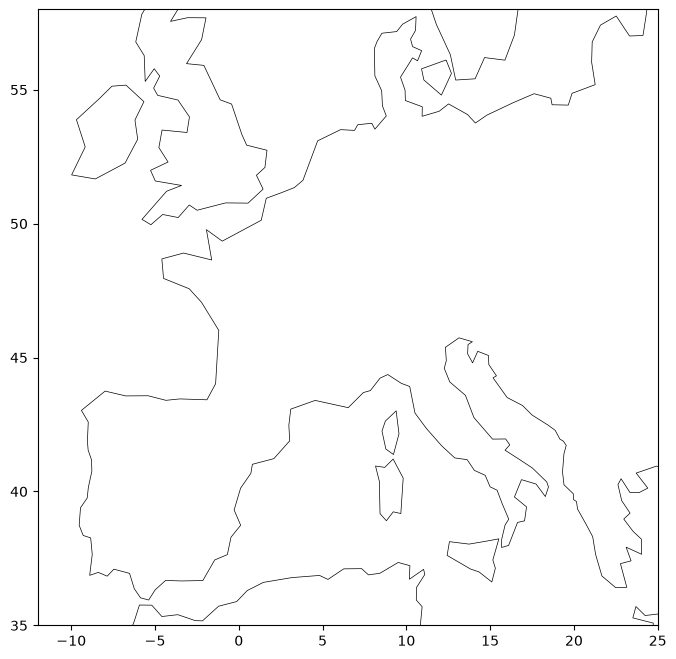

In [4]:
framed = Map(crs=4326).coastlines().set_bounds([-12, 35, 25, 58])
vp = framed.viewport
print("crs:   ", vp.crs)
print("bounds:", vp.bounds)
print("globe: ", vp.globe)

Note the contrast with an unframed map, whose `bounds` is `None` — the figure has not been told where to look, so
there is nothing to report.

unframed bounds:

 None


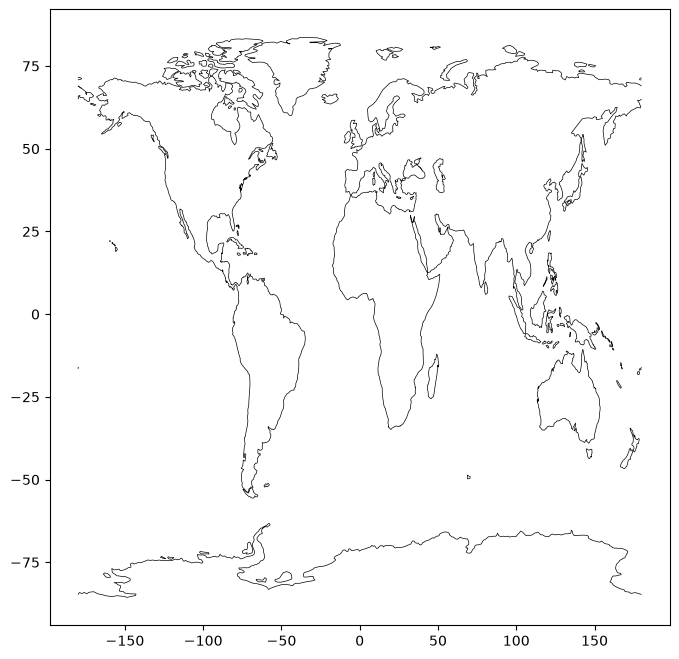

In [5]:
print("unframed bounds:", Map(crs=4326).coastlines().viewport.bounds)

## Locator insets — `inset`

A detail map is useless without context. `inset()` adds a small map in the corner showing where the main map's
extent sits in a wider area, with the extent drawn on it — the standard locator you see in any atlas.

| argument | meaning | typical value |
|---|---|---|
| `position` | which corner | `"upper right"` (default), `"lower left"`, … |
| `size` | inset size as a fraction of the axes | `0.28` default |
| `extent` | what the inset itself shows | `None` = a sensible wider area |
| `reference` | reference layers drawn on the inset | `("land", "coastlines")` |
| `crs` / `globe` | the inset's own projection | `None` = the parent's |

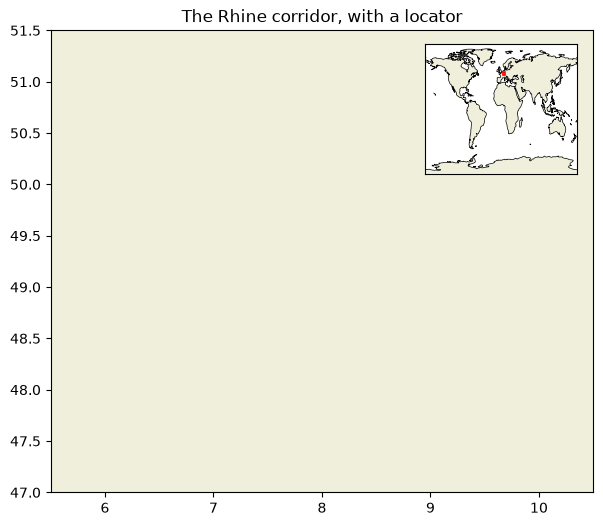

In [6]:
detail = Map(crs=4326, figsize=(7, 6))
detail.coastlines()
detail.land()
detail.set_bounds([5.5, 47.0, 10.5, 51.5])
detail.inset()
detail.set_title("The Rhine corridor, with a locator")
detail.fig;

The inset in the corner carries land and coastlines and an outline of the main map's extent. A reader who has
never heard of the Rhine now knows they are looking at west-central Europe.

## Putting the inset on a globe

The inset takes its own `crs` and `globe`, which is the most useful variant: a flat detail map with a *globe*
locator removes any doubt about which hemisphere you are in.

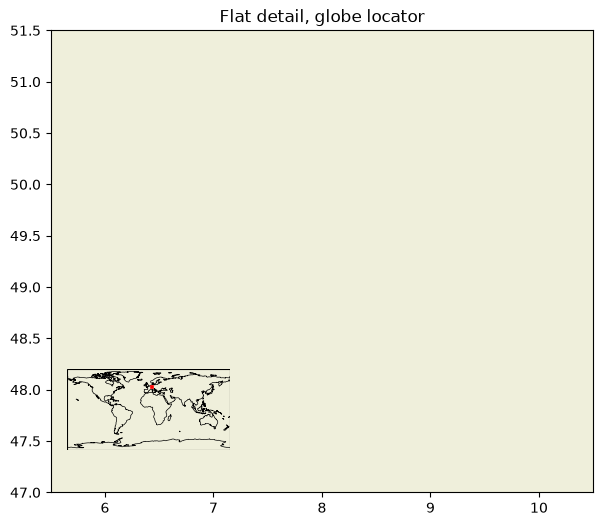

In [7]:
detail = Map(crs=4326, figsize=(7, 6))
detail.coastlines()
detail.land()
detail.set_bounds([5.5, 47.0, 10.5, 51.5])
detail.inset(globe=True, position="lower left", size=0.3)
detail.set_title("Flat detail, globe locator")
detail.fig;

The locator is reached afterwards through the `locator` property, so it can be decorated like any other map.

In [8]:
print("locator is a:", type(detail.locator).__name__)
print("locator layers:", detail.locator.layer_ids)

locator is a: Map
locator layers: ['land-1', 'coastlines-1', 'custom-1']


## Cross-referencing two maps — `mark_extent`

`inset` builds its own small map. When you already have **two** maps and want one to show the other's extent,
`mark_extent` draws that extent as an outline on the receiving map.

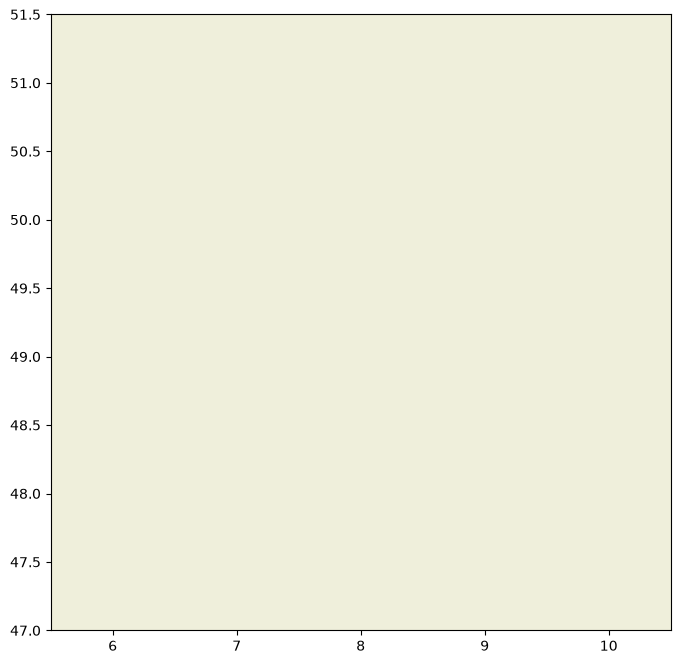

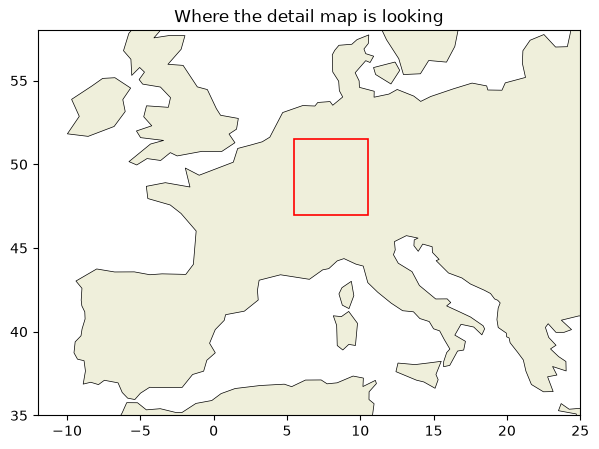

In [9]:
zoom = Map(crs=4326).coastlines().land().set_bounds([5.5, 47.0, 10.5, 51.5])

context = Map(crs=4326, figsize=(7, 5))
context.coastlines()
context.land()
context.set_bounds([-12, 35, 25, 58])
context.mark_extent(zoom)
context.set_title("Where the detail map is looking")
context.fig;

The rectangle is the `zoom` map's extent drawn on `context`. This is the two-figure version of a locator: a
side-by-side detail-and-context pair, where the context panel marks what the detail panel shows. Combine it with
[`17_multi_panel_figures`](17_multi_panel_figures.ipynb) to lay both out in one figure.

## Takeaway

- `set_bounds([w, s, e, n])` frames the map; with no argument it frames on the data, and `padding` adds margin.
- Explicit framing is what makes two figures comparable.
- `viewport` reads the framing back as a value — `bounds` is `None` until the map has been framed.
- `inset()` adds a self-contained locator; `globe=True` makes it unmistakable, and `locator` reaches it after.
- `mark_extent(other)` draws one map's extent on another, for detail-and-context pairs.

Next: [`17_multi_panel_figures`](17_multi_panel_figures.ipynb).